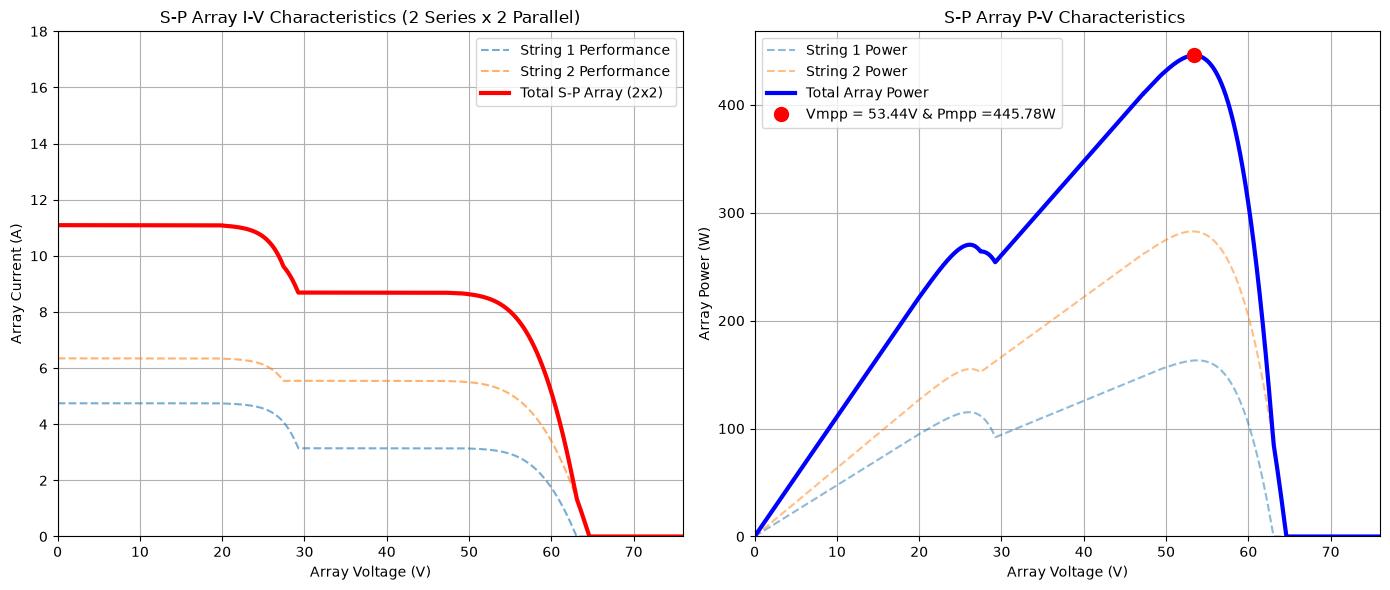

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve


k = 1.3806503e-23   
q = 1.60217646e-19

Isc = 8      
Voc = 38   
Vmp = 32 
Imp = 7.5   
Ns = 54            
Ki = 0.0032
Kv = -0.123
n = 1.3            

Rp = 415.405        
Rs = 0.221          
Ion = 9.825e-8    

T= 25 + 273.15
Vt = (Ns * k * T) / q  

def solve_module_voltage(I, G):
    Ipv = (Isc + Ki * (T - 298.15)) * (G / 1000)
    Io = Ion * ((T / 298.15)**3) * np.exp(((q * 1.12) / (n * k)) * (1/298.15 - 1/T))
    
    V = np.zeros_like(I)
    for i in range(len(I)):
        if I[i] > Ipv + Io: 
            V[i] = 0
            continue
        v_guess = 0.0
        for _ in range(5):  
            arg = (Ipv + Io - I[i] - v_guess / Rp) / Io
            if arg <= 0:
                v_guess = 0
                break
            v_guess = n * Vt * np.log(arg) - I[i] * Rs
        V[i] = max(0, v_guess)
    return V

N_ser = 2 # 2 modules are connected in series to form a string
N_par = 2 # then three such strings are connected in parallel

irradiance_matrix_sp = np.array([[600, 400],
                                 [700 , 800],])

I_sweep = np.linspace(0, Isc , 5000)

V_array_total = np.linspace(0, N_ser * Voc , 5000)  
I_array_total = np.zeros_like(V_array_total)

string_data = []


for string_idx in range(N_par):
    V_string = np.zeros_like(I_sweep)
    
    for mod_idx in range(N_ser):
        G = irradiance_matrix_sp[string_idx, mod_idx % irradiance_matrix_sp.shape[1]]
        V_string += solve_module_voltage(I_sweep, G)


    I_interpolated = np.interp(V_array_total, V_string[::-1], I_sweep[::-1], left=I_sweep[-1], right=0)
    
    I_array_total += I_interpolated
    string_data.append((V_string, I_sweep, I_interpolated))

P_array_total = V_array_total * I_array_total

idx_mpp = np.argmax(P_array_total)
V_mpp = V_array_total[idx_mpp]
I_mpp = I_array_total[idx_mpp]
P_mpp = P_array_total[idx_mpp]
plt.figure(figsize=(14, 6))

# I-V Characteristics
plt.subplot(1, 2, 1)
for idx, (V_str, I_str, I_interp) in enumerate(string_data):
    plt.plot(V_array_total, I_interp, '--', label=f'String {idx+1} Performance', alpha=0.6)

plt.plot(V_array_total, I_array_total, 'r', linewidth=3, label=f'Total S-P Array ({N_ser}x{N_par})')
plt.title(f'S-P Array I-V Characteristics ({N_ser} Series x {N_par} Parallel)')
plt.xlabel('Array Voltage (V)')
plt.ylabel('Array Current (A)')
plt.grid(True)
plt.legend()
plt.xlim(0, N_ser * Voc)
plt.ylim(0, (N_par * Isc) + 2)

# P-V Characteristics
plt.subplot(1, 2, 2)
for idx, (V_str, I_str, I_interp) in enumerate(string_data):
    plt.plot(V_array_total, V_array_total * I_interp, '--', label=f'String {idx+1} Power', alpha=0.5)

plt.plot(V_array_total, P_array_total, 'b', linewidth=3, label='Total Array Power')
plt.plot(V_mpp, P_mpp, 'ro', markersize=10, label=f'Vmpp = {V_mpp:.2f}V & Pmpp ={P_mpp:.2f}W')
plt.title('S-P Array P-V Characteristics ')
plt.xlabel('Array Voltage (V)')
plt.ylabel('Array Power (W)')
plt.grid(True)
plt.legend()
plt.xlim(0, N_ser * Voc)
plt.ylim(bottom=0)
plt.savefig('pv_array_characteristics.png')
plt.tight_layout()
plt.show()